# Make diagram of example of method differences for MIUA paper

In [1]:
# imports
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import colormaps
import seaborn as sns
import SimpleITK as sitk

sns.set_style("whitegrid", {'xtick.bottom': True})

In [2]:
# functions to take json file and return array of dice scores, or return hausdorff distance
def get_dice_scores(json_file):
    with open(json_file) as f:
        data = json.load(f)

    # Extract Dice scores from "metric_per_case"
    dice_scores = [
        case["metrics"]["1"]["Dice"] for case in data["metric_per_case"]
    ]

    return dice_scores


def get_hausdorff_distances(json_file):
    with open(json_file) as f:
        data = json.load(f)

    # Extract Hausdorff distances from "metric_per_case"
    hausdorff_distances = [
        case["metrics"]["1"]["Hausdorff_95"] for case in data["metric_per_case"]
    ]

    return hausdorff_distances

## External results on all of SKMTEA (not fold-wise)

In [3]:
data_path = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/'

# get only the subfolders that end in _all_skmtea
subfolders = [f.name for f in os.scandir(data_path) if f.is_dir() and f.name.endswith("_all_skmtea")]

# discount images and labels folders (starts with)
subfolders = [f for f in subfolders if not f.startswith("images") and not f.startswith("labels") 
              and not f.startswith("ResEnc") and not f.startswith("clahe_hist_match")
              and not f.startswith("zscore_postproc") and "hist_match" not in f and "fold" not in f]
subfolders

['clip_rescale_preds_all_skmtea',
 'nyul_preds_all_skmtea',
 'gmm_preds_all_skmtea',
 'zscore_preds_all_skmtea',
 'clahe_preds_all_skmtea',
 'rescale_preds_all_skmtea',
 'hist_eq_preds_all_skmtea']

In [4]:
# reorder the subfolders using the order of the methods (starts with)
method_order = ["zscore_preds", "rescale", "clip_rescale", "hist_eq", "clahe_preds", "resenc", "nyul", "gmm"]
# Sort by checking which method each subfolder starts with
subfolders = sorted(
    subfolders,
    key=lambda x: next((method_order.index(m) for m in method_order if x.lower().startswith(m.lower())), float('inf'))
)
subfolders

['zscore_preds_all_skmtea',
 'rescale_preds_all_skmtea',
 'clip_rescale_preds_all_skmtea',
 'hist_eq_preds_all_skmtea',
 'clahe_preds_all_skmtea',
 'nyul_preds_all_skmtea',
 'gmm_preds_all_skmtea']

In [5]:
# for each folder, get dice scores and add to pandas dataframe

# create empty dataframe
external_all_df = pd.DataFrame()

for folder in subfolders:
    json_path = os.path.join(data_path, folder, 'summary.json')
    dice_scores = get_dice_scores(json_path)
    external_all_df[folder] = dice_scores

# turn dice to percentage
external_all_df = external_all_df * 100
external_all_df.head()

,zscore_preds_all_skmtea,rescale_preds_all_skmtea,clip_rescale_preds_all_skmtea,hist_eq_preds_all_skmtea,clahe_preds_all_skmtea,nyul_preds_all_skmtea,gmm_preds_all_skmtea
0,80.279842,79.928753,80.192836,80.126713,80.330559,80.185203,79.931339
1,80.597486,80.664459,80.543079,79.832012,80.892747,80.880864,80.485006
2,82.420316,81.804615,82.013961,81.932241,81.715126,82.554881,81.935379
3,79.757396,79.706789,79.885147,79.510035,79.919987,79.360876,79.845018
4,82.373550,82.036228,82.280699,81.970770,82.547913,82.397004,81.892362


In [6]:
# rename columns
external_all_df.columns = [
    "Z-score",
    "Min-max",
    "R. Min-max",
    "HE",
    "CLAHE",
    "Nyúl",
    "GMM"
]

## Look at images that have most performance variance

In [7]:
# across external dataframe, get mean and standard deviation of dice scores across images 
# to see which images vary the most in dice score across methods, and which are more consistent
external_means = external_all_df.mean(axis=1)
external_stds = external_all_df.std(axis=1)

# add to dataframe
external_all_df["Mean"] = external_means
external_all_df["Std"] = external_stds
external_all_df.head()

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM,Mean,Std
0,80.279842,79.928753,80.192836,80.126713,80.330559,80.185203,79.931339,80.139321,0.157608
1,80.597486,80.664459,80.543079,79.832012,80.892747,80.880864,80.485006,80.556522,0.356320
2,82.420316,81.804615,82.013961,81.932241,81.715126,82.554881,81.935379,82.053788,0.314271
3,79.757396,79.706789,79.885147,79.510035,79.919987,79.360876,79.845018,79.712178,0.207002
4,82.373550,82.036228,82.280699,81.970770,82.547913,82.397004,81.892362,82.214075,0.248028


In [8]:
# sort by standard deviation to see which images vary the most in dice score across methods
external_all_df_sorted = external_all_df.sort_values(by="Std", ascending=False)
external_all_df_sorted.head(10)

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM,Mean,Std
77,79.711132,73.855762,73.297540,82.364269,80.059630,83.028679,72.316942,77.804850,4.524432
53,74.301681,68.737456,68.661329,76.652839,76.157438,78.435378,68.577038,73.074737,4.302465
111,64.949984,64.259448,61.640651,66.915288,60.690450,67.767533,62.447210,64.095795,2.662379
127,79.382537,76.370084,76.515607,79.625409,81.272660,81.197261,74.701373,78.437847,2.578280
52,77.599805,76.186086,73.197515,76.742900,77.828452,78.441899,74.416416,76.344725,1.914063
87,74.414569,75.541082,75.395914,77.647207,76.806234,78.579327,74.116374,76.071530,1.664211
128,70.925740,69.541371,72.282400,72.165694,72.765050,73.470640,71.168029,71.759846,1.312926
121,71.589096,71.664786,71.795928,69.386526,72.966775,73.078125,72.981890,71.923304,1.302116
83,82.093445,80.297757,80.136087,82.264274,82.413085,81.769400,79.324564,81.185516,1.237501
126,73.485830,74.222662,73.021784,73.099949,76.002615,75.286067,73.245495,74.052057,1.175847


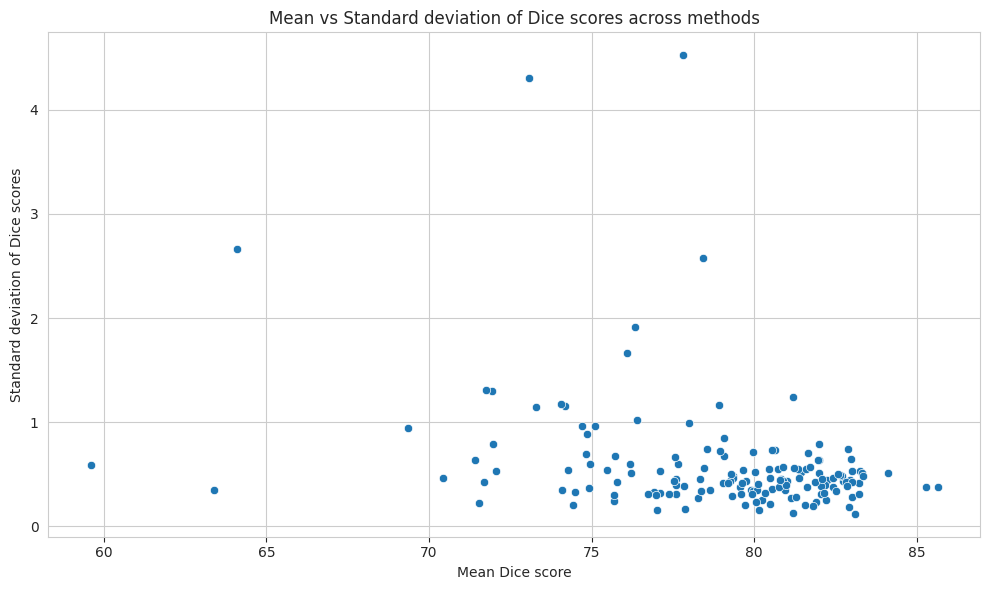

In [9]:
# do lower mean dice scores correspond to higher standard deviation? plot mean vs std
plt.figure(figsize=(10, 6))
sns.scatterplot(data=external_all_df, x="Mean", y="Std")
plt.xlabel("Mean Dice score")
plt.ylabel("Standard deviation of Dice scores")
plt.title("Mean vs Standard deviation of Dice scores across methods")
plt.tight_layout()
plt.show()

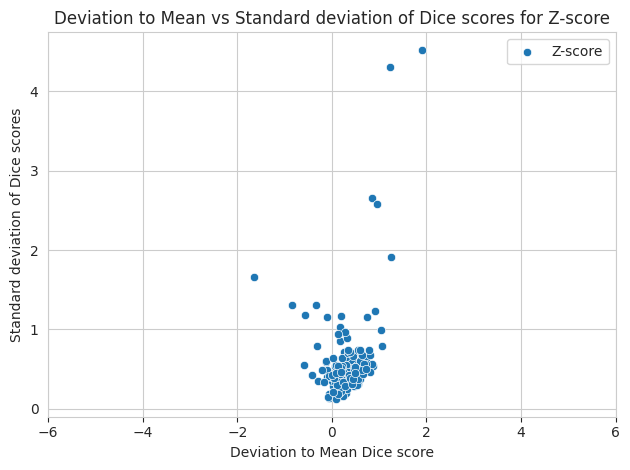

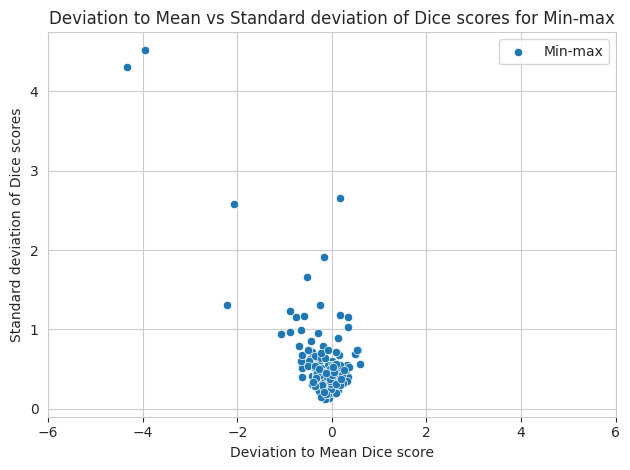

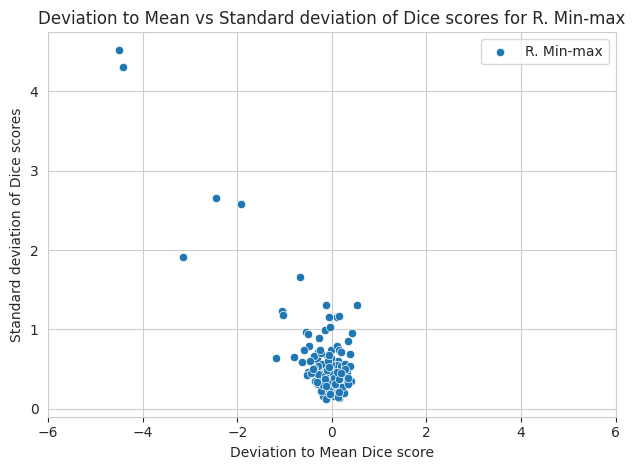

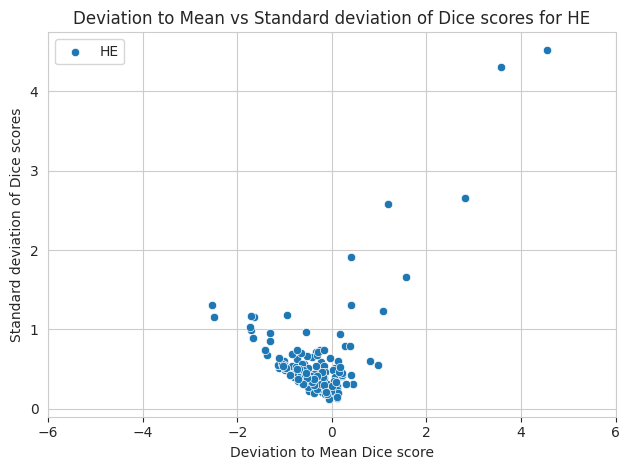

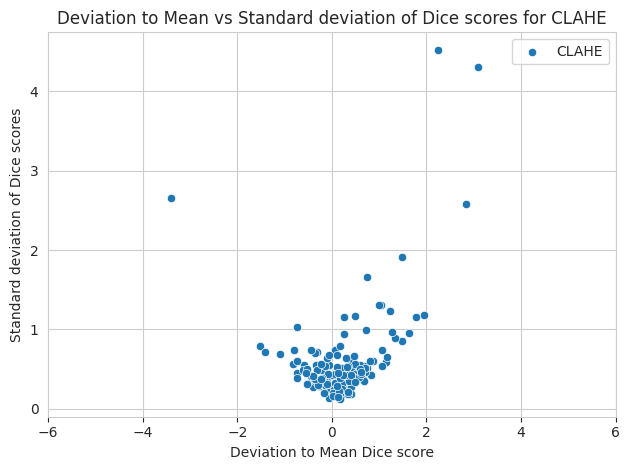

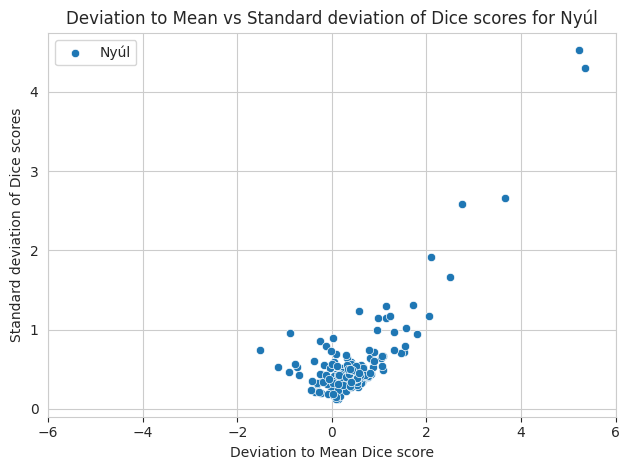

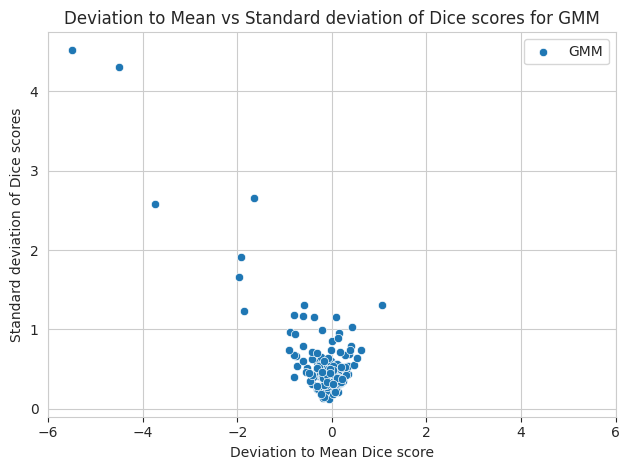

In [10]:
# does a particular method deviation to mean correspond to the standard deviation? plot deviation to mean vs std for each method
for method in external_all_df.columns[:-2]:  # exclude Mean and Std columns
    deviation_to_mean = external_all_df[method] - external_all_df["Mean"]
    sns.scatterplot(x=deviation_to_mean, y=external_all_df["Std"], label=method)
    # set x limits to -5 to 5
    plt.xlim(-6, 6)
    plt.xlabel("Deviation to Mean Dice score")
    plt.ylabel("Standard deviation of Dice scores")
    plt.title(f"Deviation to Mean vs Standard deviation of Dice scores for {method}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Try visualising the differences across the images with the most variation

In [11]:
# get index of image with highest standard deviation
index_highest_std = external_all_df["Std"].idxmax()
print(f"Image with highest standard deviation: {index_highest_std}, Std: {external_all_df.loc[index_highest_std, 'Std']}, Mean: {external_all_df.loc[index_highest_std, 'Mean']}")

Image with highest standard deviation: 77, Std: 4.524432071295059, Mean: 77.80485048369101


In [12]:
# read in the image, label, and all predictions for the image with the highest standard deviation in dice scores across methods
im_name = f"SKMTEA_{index_highest_std+1:03d}_0000.nii.gz"
seg_name = f"SKMTEA_{index_highest_std+1:03d}.nii.gz"

# paths
im_path = os.path.join(data_path, '../images_all_skmtea', im_name)
gt_path = os.path.join(data_path, '../labels_all_skmtea', seg_name)

# method predictions
method_pred_paths = {}
for folder in subfolders:
    pred_path = os.path.join(data_path, folder, seg_name)
    method_pred_paths[folder] = pred_path

(160, 266, 341)
(160, 266, 341)


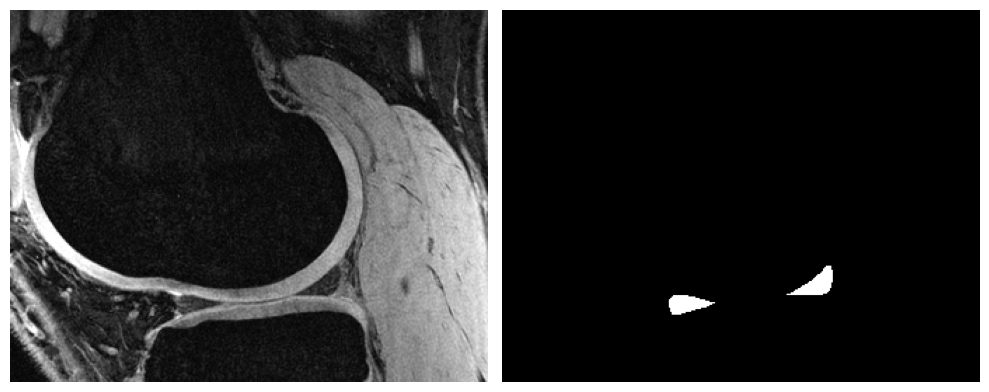

In [13]:
# load image
image = sitk.ReadImage(im_path)
image_array = sitk.GetArrayFromImage(image)
print(image_array.shape)

label = sitk.ReadImage(gt_path)
label_array = sitk.GetArrayFromImage(label)
print(label_array.shape)

# plot a slice of image and label
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(image_array[115,:], vmax=np.percentile(image_array[115,:], 99.5), cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(label_array[115,:], cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
# load all predictions into a dictionary of arrays
pred_arrays = {}
for method, path in method_pred_paths.items():
    pred = sitk.ReadImage(path)
    pred_array = sitk.GetArrayFromImage(pred)
    pred_arrays[method] = pred_array
    print(f"{method}: {pred_array.shape}")

zscore_preds_all_skmtea: (160, 266, 341)
rescale_preds_all_skmtea: (160, 266, 341)
clip_rescale_preds_all_skmtea: (160, 266, 341)
hist_eq_preds_all_skmtea: (160, 266, 341)
clahe_preds_all_skmtea: (160, 266, 341)
nyul_preds_all_skmtea: (160, 266, 341)
gmm_preds_all_skmtea: (160, 266, 341)


In [15]:
def crop_rotate_for_figure(array, crop_indices):
    # crop the array using the crop indices
    cropped_array = array[crop_indices[0]:crop_indices[1], crop_indices[2]:crop_indices[3]]
    # rotate the array 90 degrees clockwise
    rotated_array = np.rot90(cropped_array, k=-1)
    return rotated_array

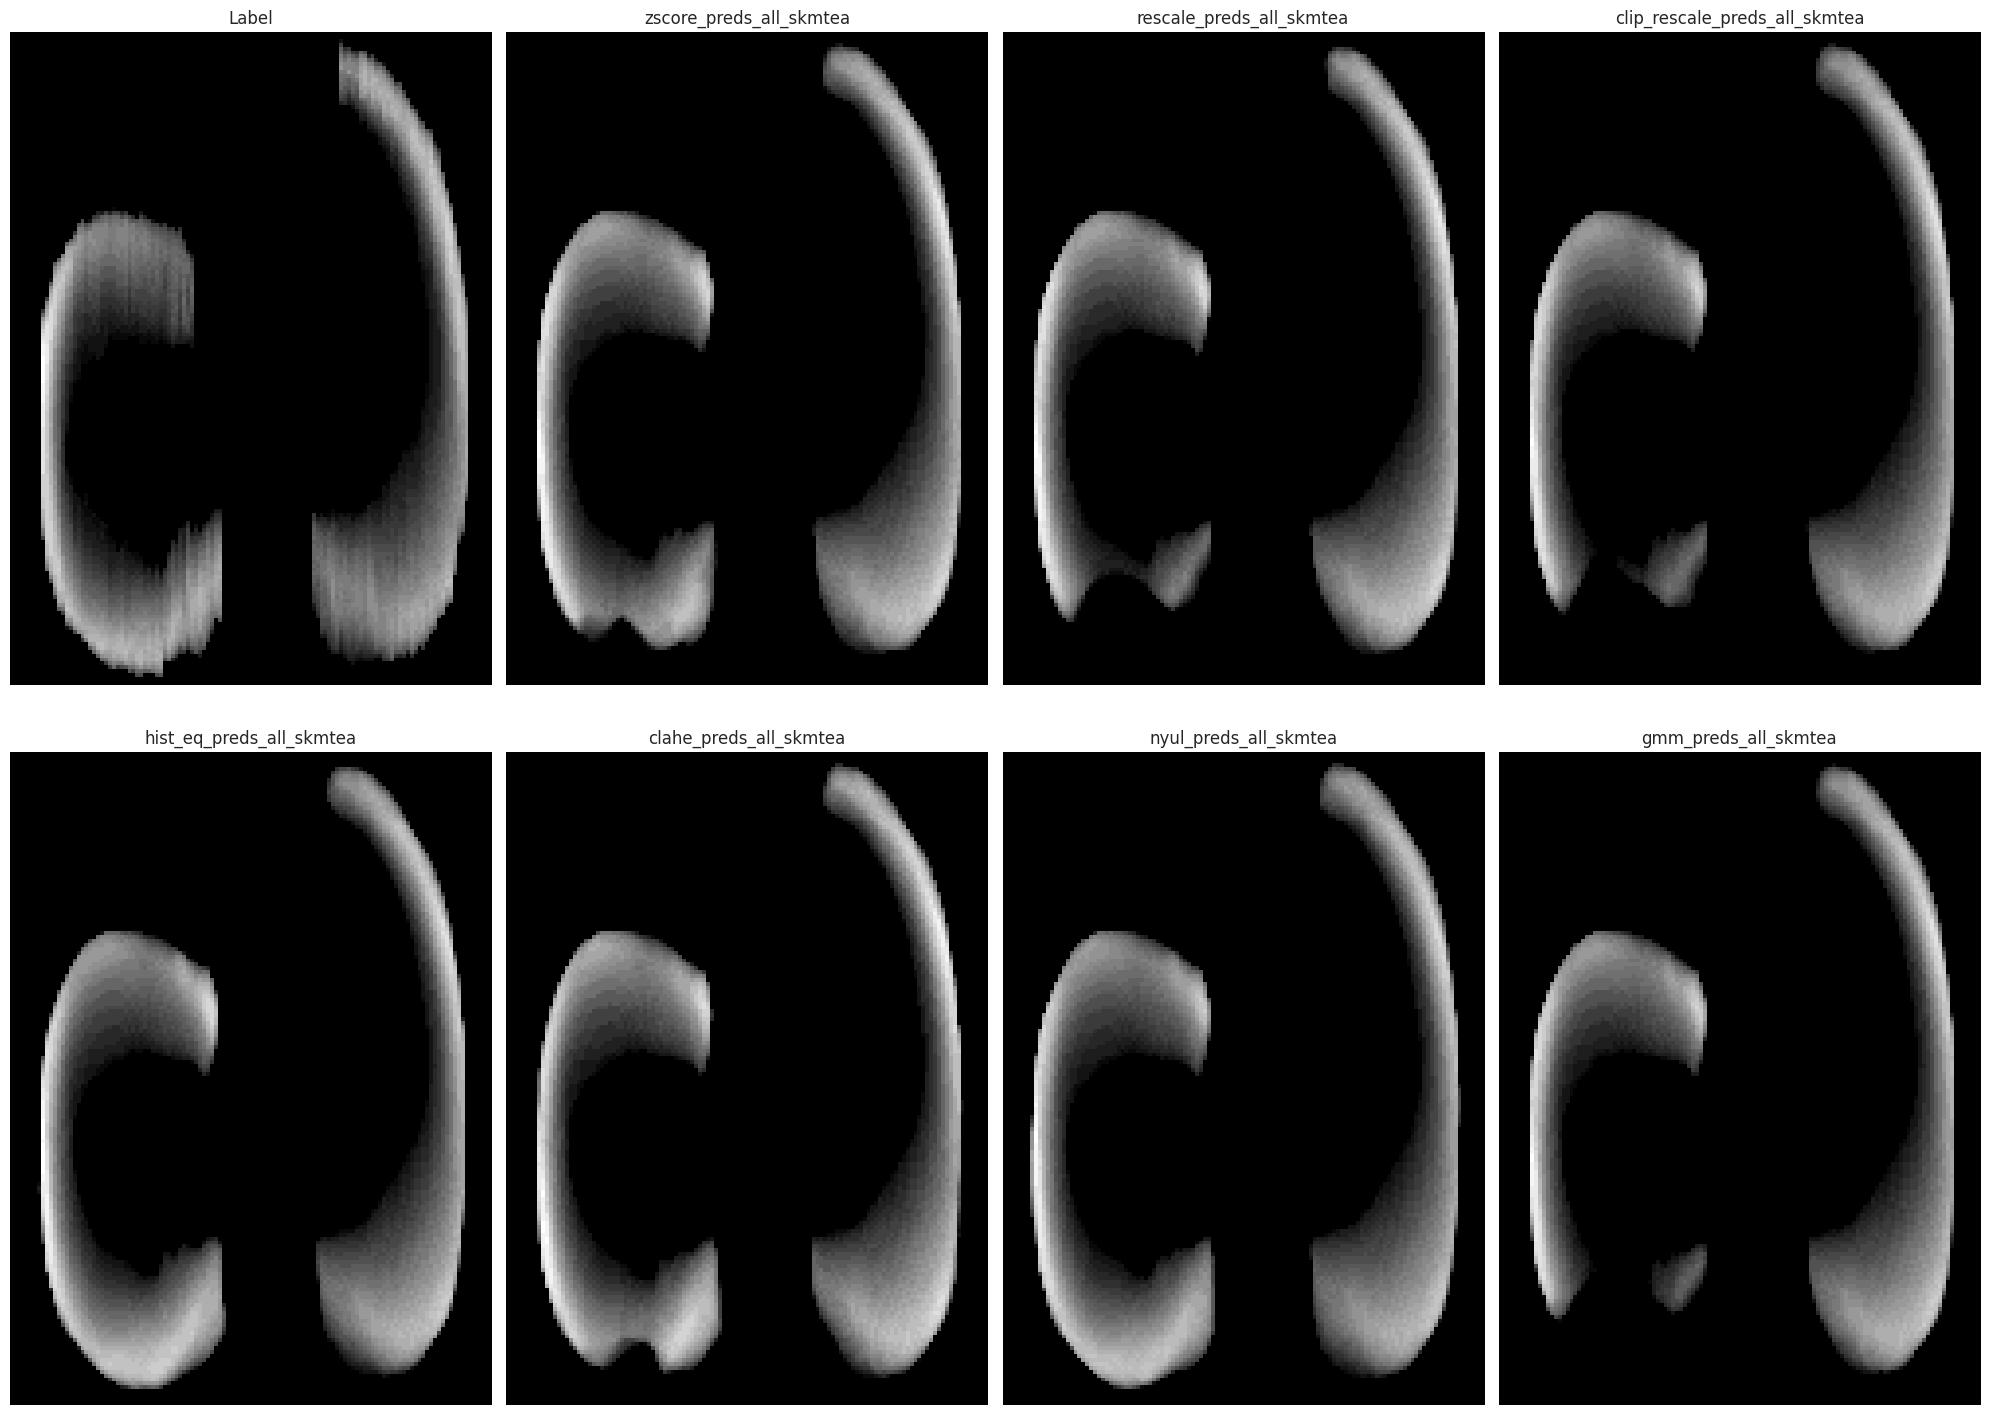

In [16]:
# for each prediction, plot the sum through the y axis
crop_indices = [22, 145, 73, 240]

# make a 8 panel figure, 4 by 2
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 15))
sum_through_y = np.sum(label_array, axis=1)

plt.subplot(2, 4, 1)
plt.imshow(crop_rotate_for_figure(sum_through_y, crop_indices), cmap="gray")
# draw red line
#§plt.axhline(y=115, color='red', linestyle='--')
plt.title("Label")
plt.axis("off")

for method, pred_array in pred_arrays.items():
    plt.subplot(2, 4, list(pred_arrays.keys()).index(method) + 2)  # start from subplot 2
    plt.imshow(crop_rotate_for_figure(np.sum(pred_array, axis=1), crop_indices), cmap="gray")
    #plt.axhline(y=115, color='red', linestyle='--')
    plt.title(method)
    plt.axis("off")

plt.tight_layout()
plt.show()

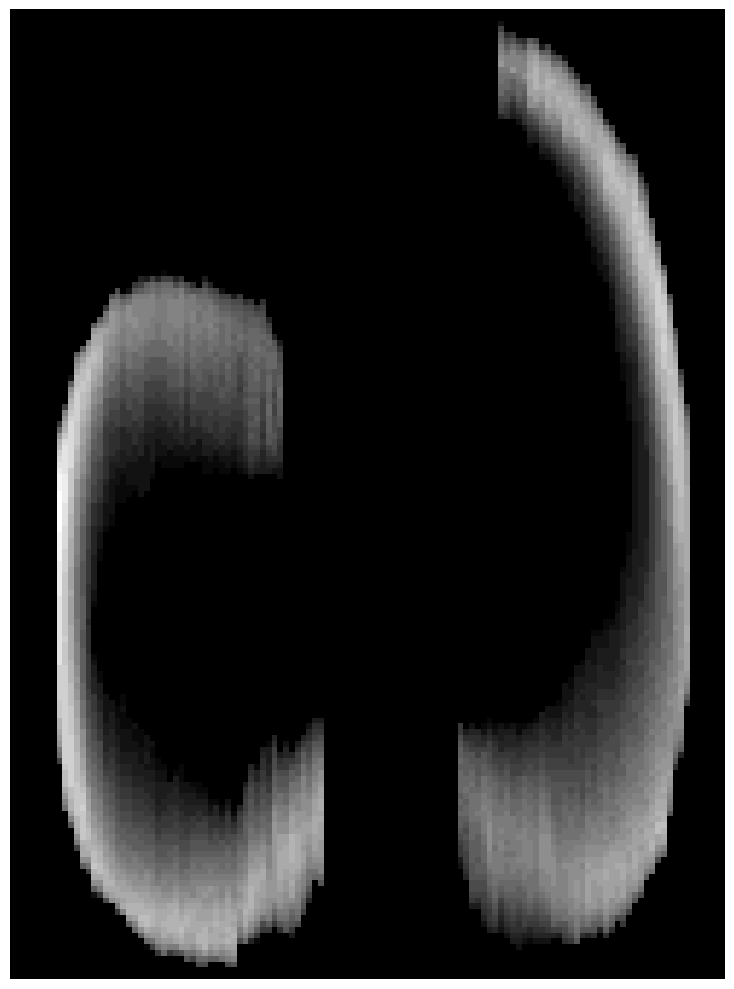

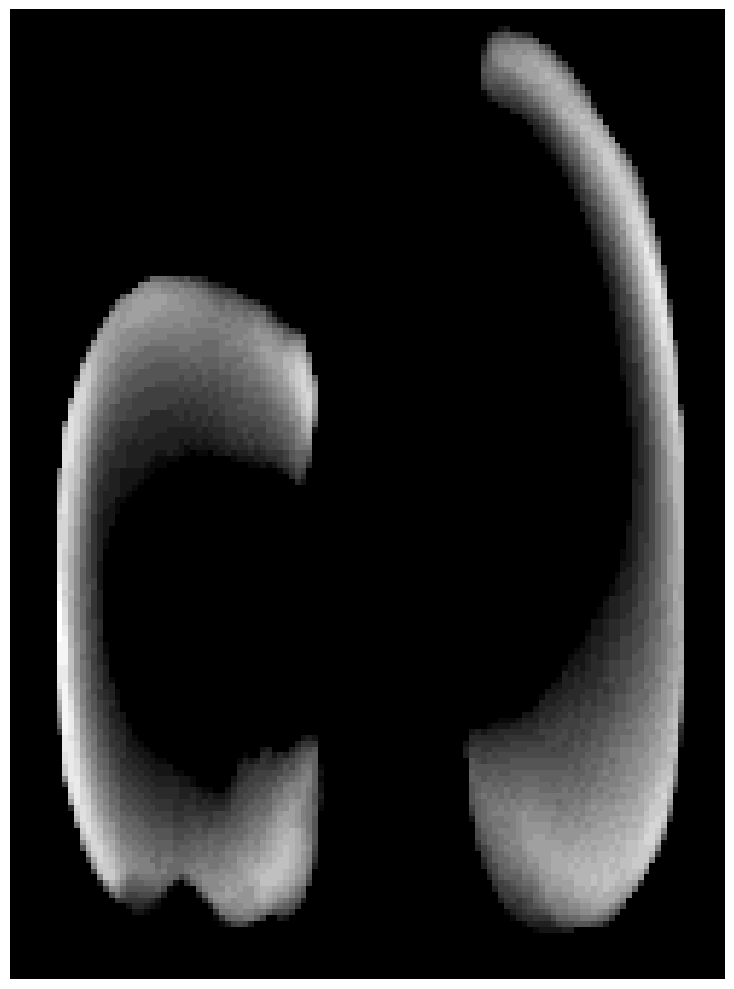

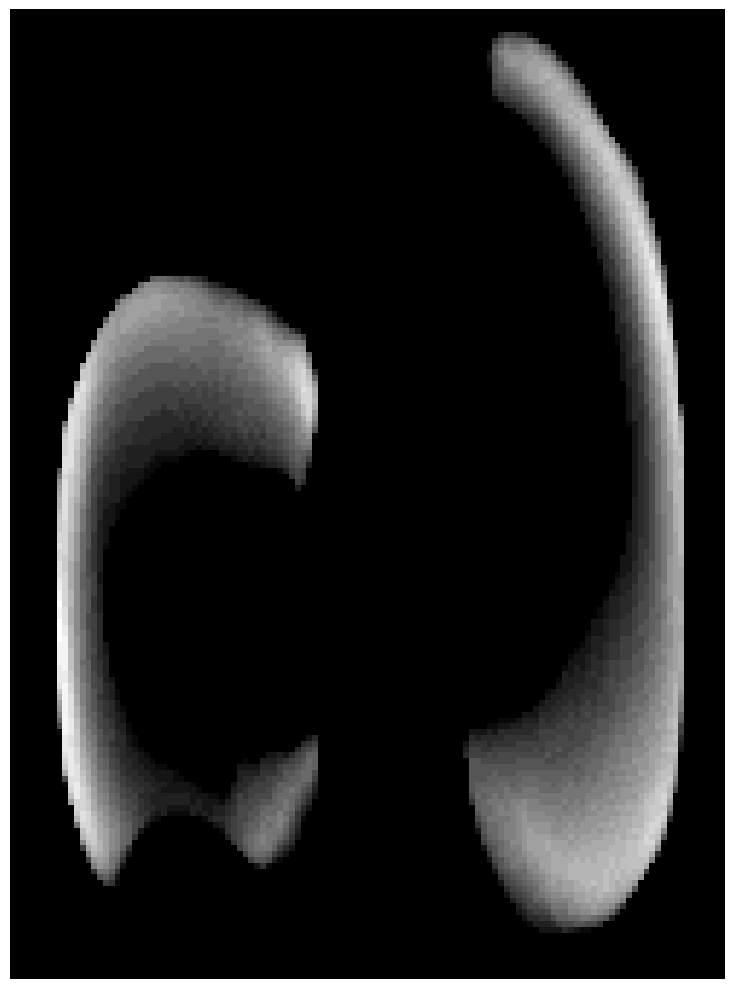

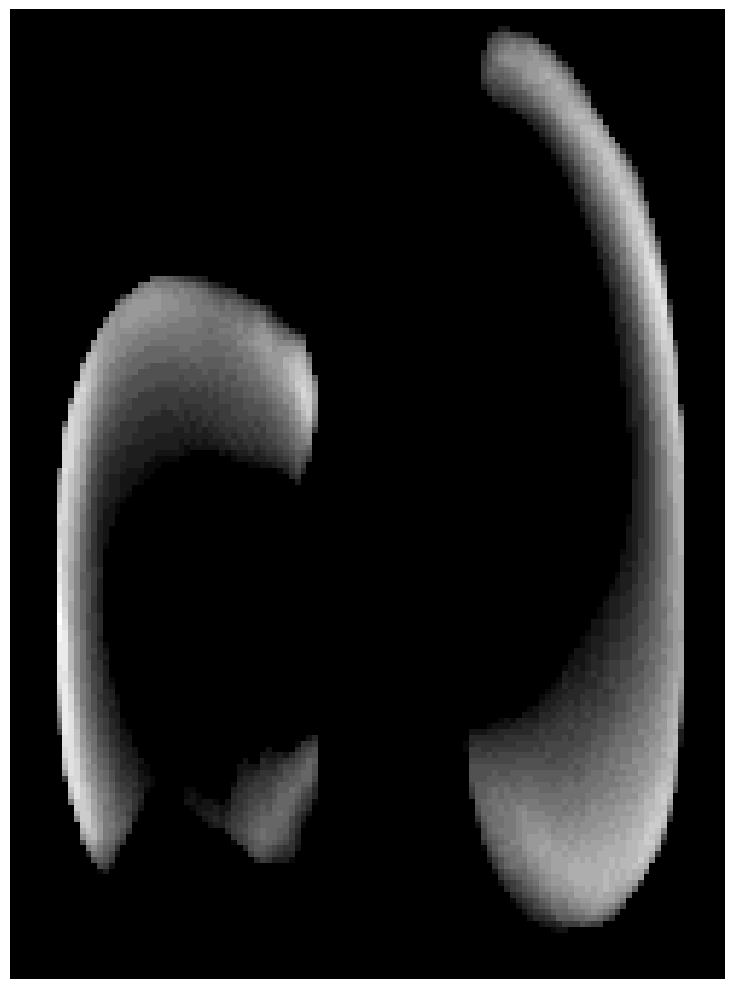

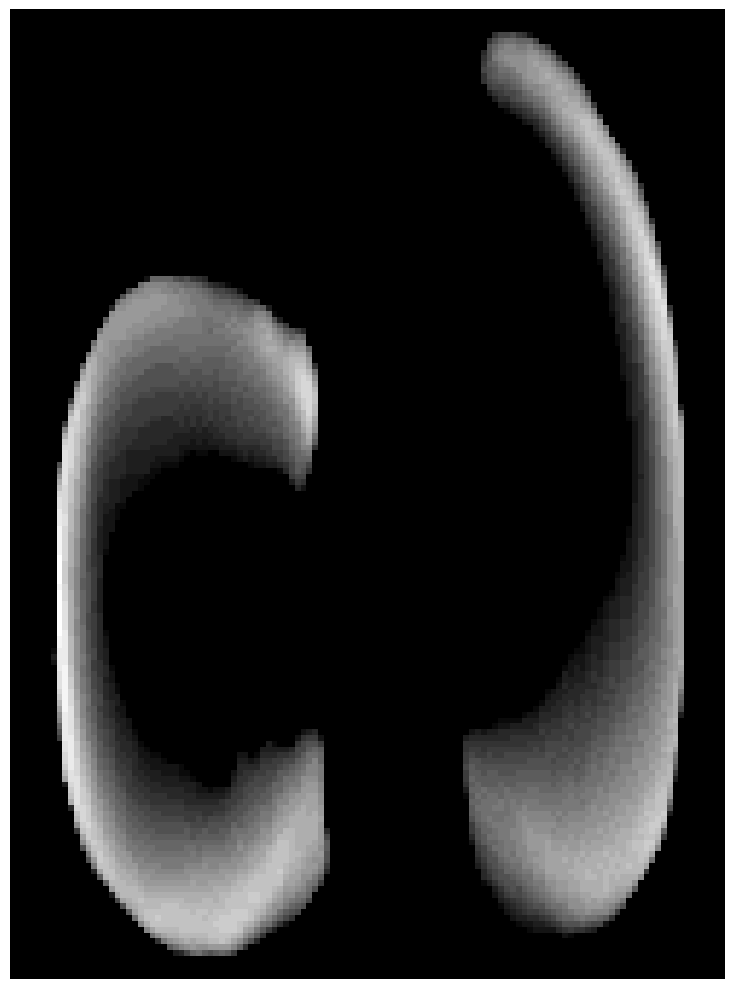

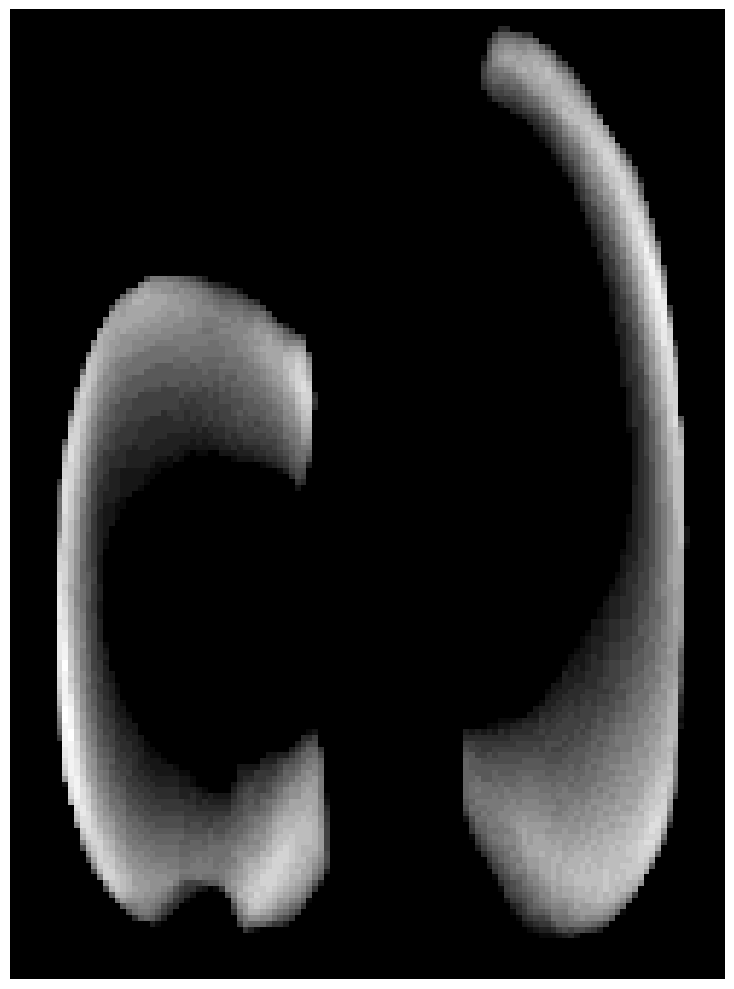

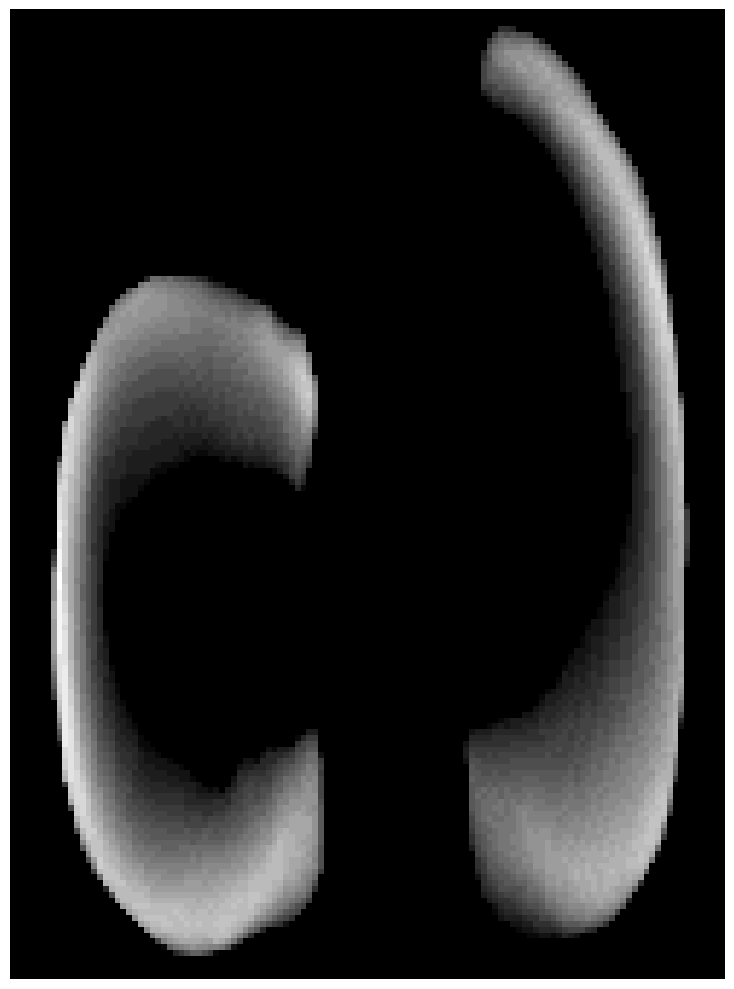

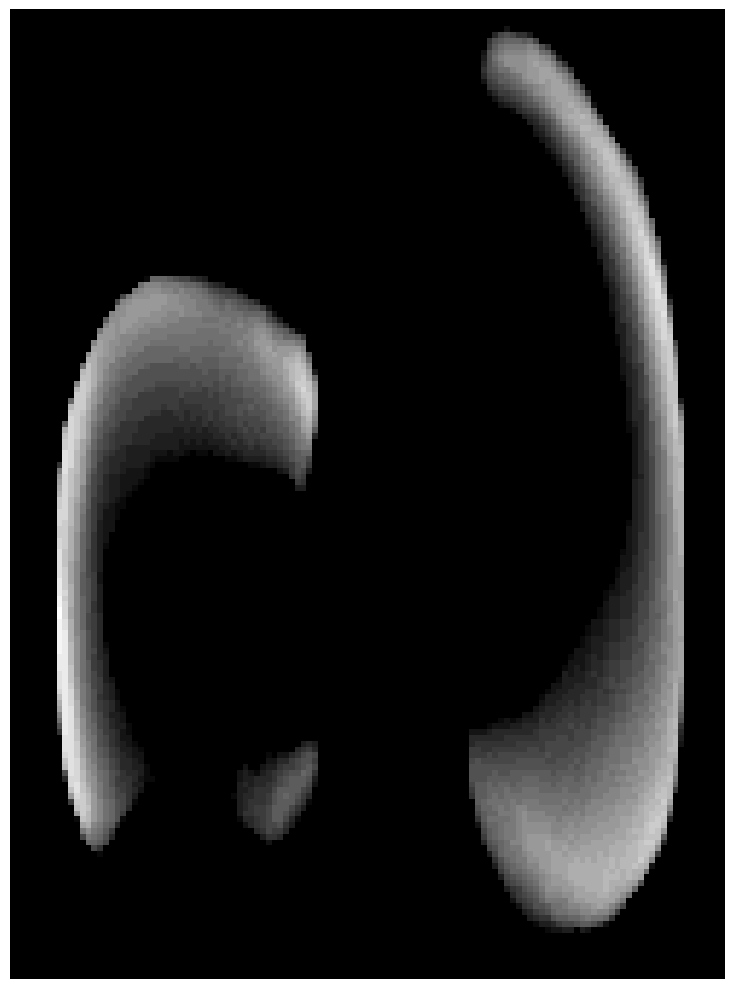

In [18]:
# for each prediction, plot the sum through the y axis
crop_indices = [22, 145, 73, 240]

# do same but save as own figures this time
sum_through_y = np.sum(label_array, axis=1)

plt.figure(figsize=(10, 10))
plt.imshow(crop_rotate_for_figure(sum_through_y, crop_indices), cmap="gray")
# draw red line
#§plt.axhline(y=115, color='red', linestyle='--')
plt.axis("off")
plt.tight_layout()
plt.savefig("label_y_sum.pdf", format="pdf", bbox_inches='tight', dpi=800)

for method, pred_array in pred_arrays.items():
    plt.figure(figsize=(10, 10))
    plt.imshow(crop_rotate_for_figure(np.sum(pred_array, axis=1), crop_indices), cmap="gray")
    #plt.axhline(y=115, color='red', linestyle='--')
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"{method}_y_sum.pdf", format="pdf", bbox_inches='tight', dpi=800)

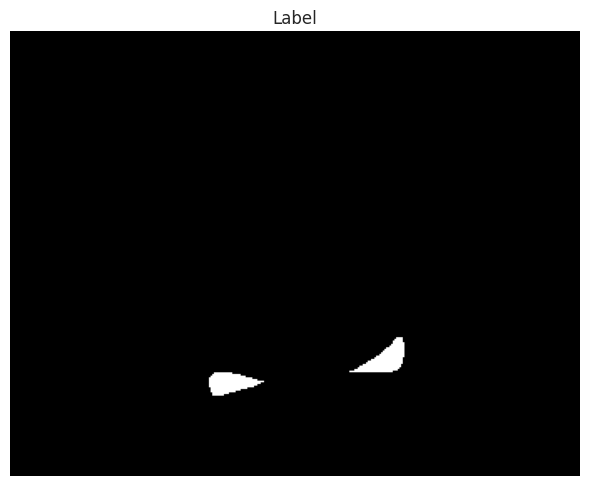

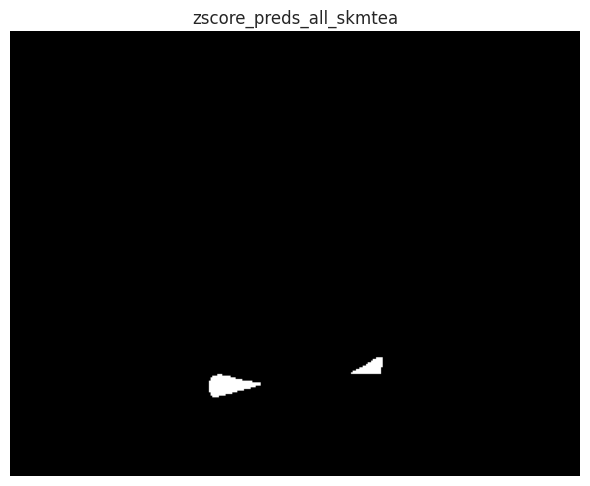

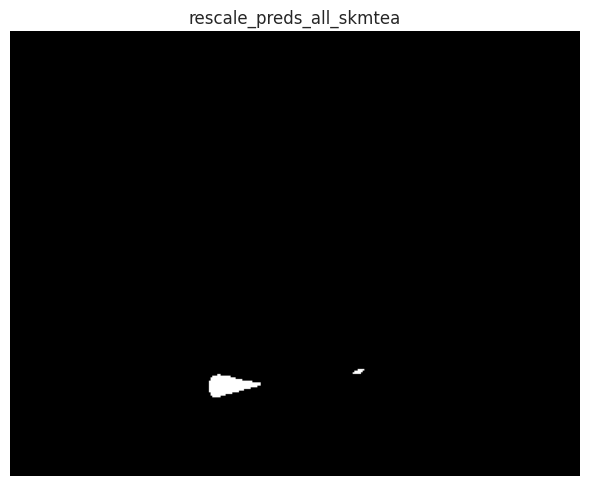

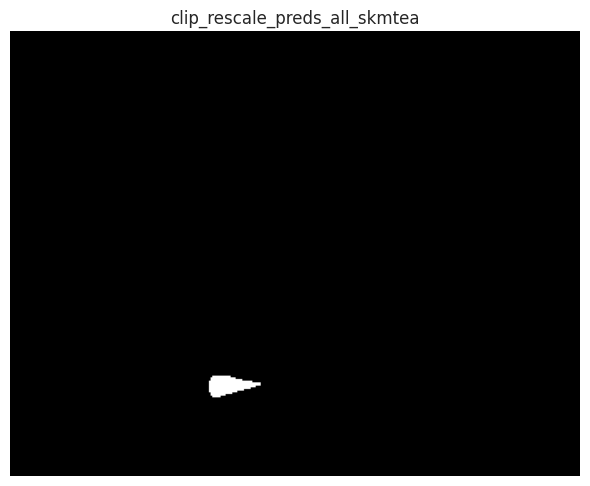

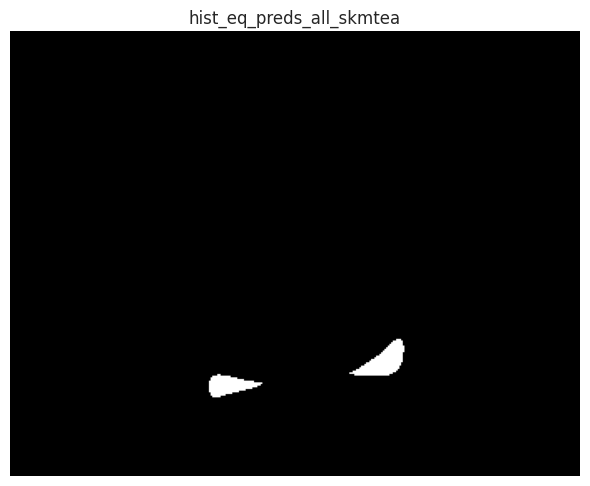

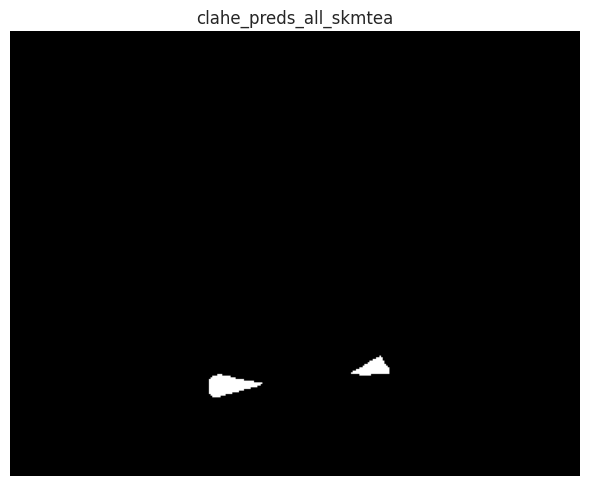

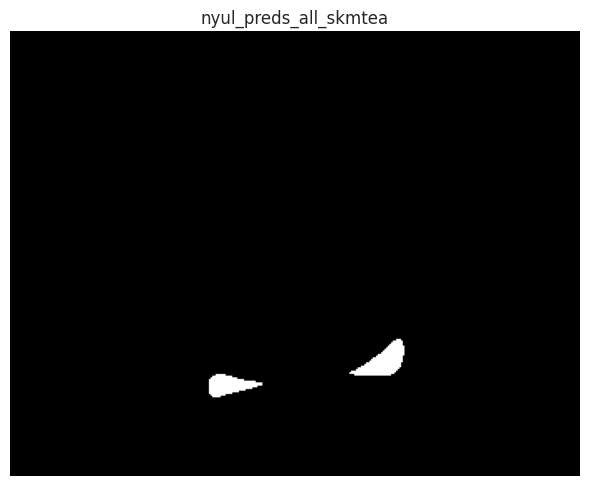

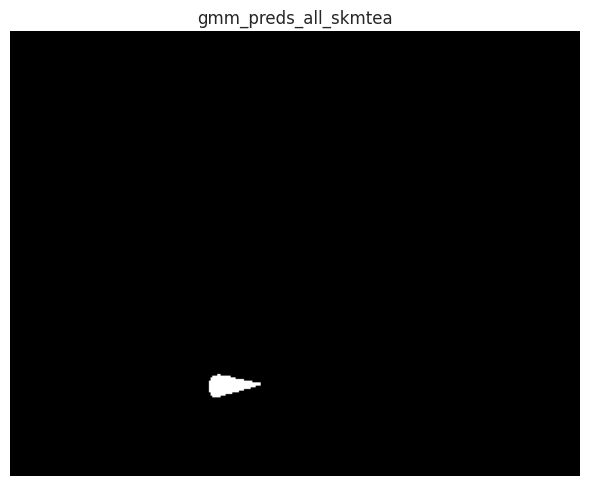

In [23]:
# for each prediction, plot 115th slice
plt.figure(figsize=(6, 6))
plt.imshow(label_array[115,:], cmap="gray")
plt.title("Label")
plt.axis("off")
plt.tight_layout()
plt.show()

for method, pred_array in pred_arrays.items():
    plt.figure(figsize=(6, 6))
    plt.imshow(pred_array[115,:], cmap="gray")
    plt.title(method)
    plt.axis("off")
    plt.tight_layout()
    plt.show()